In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Makes plots look clean
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [4]:
from pathlib import Path
import os

data_path = '/home/bkm/Downloads/Desktop/F1 EDA Project/f1-eda/data/processed/monza_2023_laps_clean.csv'
laps = pd.read_csv(data_path)
print(laps.shape)
laps.head()

(864, 31)


,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 01:25:15.943000,VER,1,86.163,2.0,1.0,NaN,NaN,28.274,29.543,...,True,Red Bull Racing,0 days 01:23:49.780000,2023-09-03 13:24:50.825,1,2.0,False,NaN,False,True
1,0 days 01:26:41.645000,VER,1,85.702,3.0,1.0,NaN,NaN,28.097,29.320,...,True,Red Bull Racing,0 days 01:25:15.943000,2023-09-03 13:26:16.988,1,2.0,False,NaN,False,True
2,0 days 01:28:07.695000,VER,1,86.050,4.0,1.0,NaN,NaN,28.145,29.474,...,True,Red Bull Racing,0 days 01:26:41.645000,2023-09-03 13:27:42.690,1,2.0,False,NaN,False,True
3,0 days 01:29:33.871000,VER,1,86.176,5.0,1.0,NaN,NaN,28.155,29.514,...,True,Red Bull Racing,0 days 01:28:07.695000,2023-09-03 13:29:08.740,1,2.0,False,NaN,False,True
4,0 days 01:31:00.708000,VER,1,86.837,6.0,1.0,NaN,NaN,28.700,29.662,...,True,Red Bull Racing,0 days 01:29:33.871000,2023-09-03 13:30:34.916,1,2.0,False,NaN,False,True


## 1. Race Position Changes Lap by Lap
How did positions evolve throughout the race? This shows every driver's 
position on each lap, revealing overtakes, pit stop strategies, and retirements.

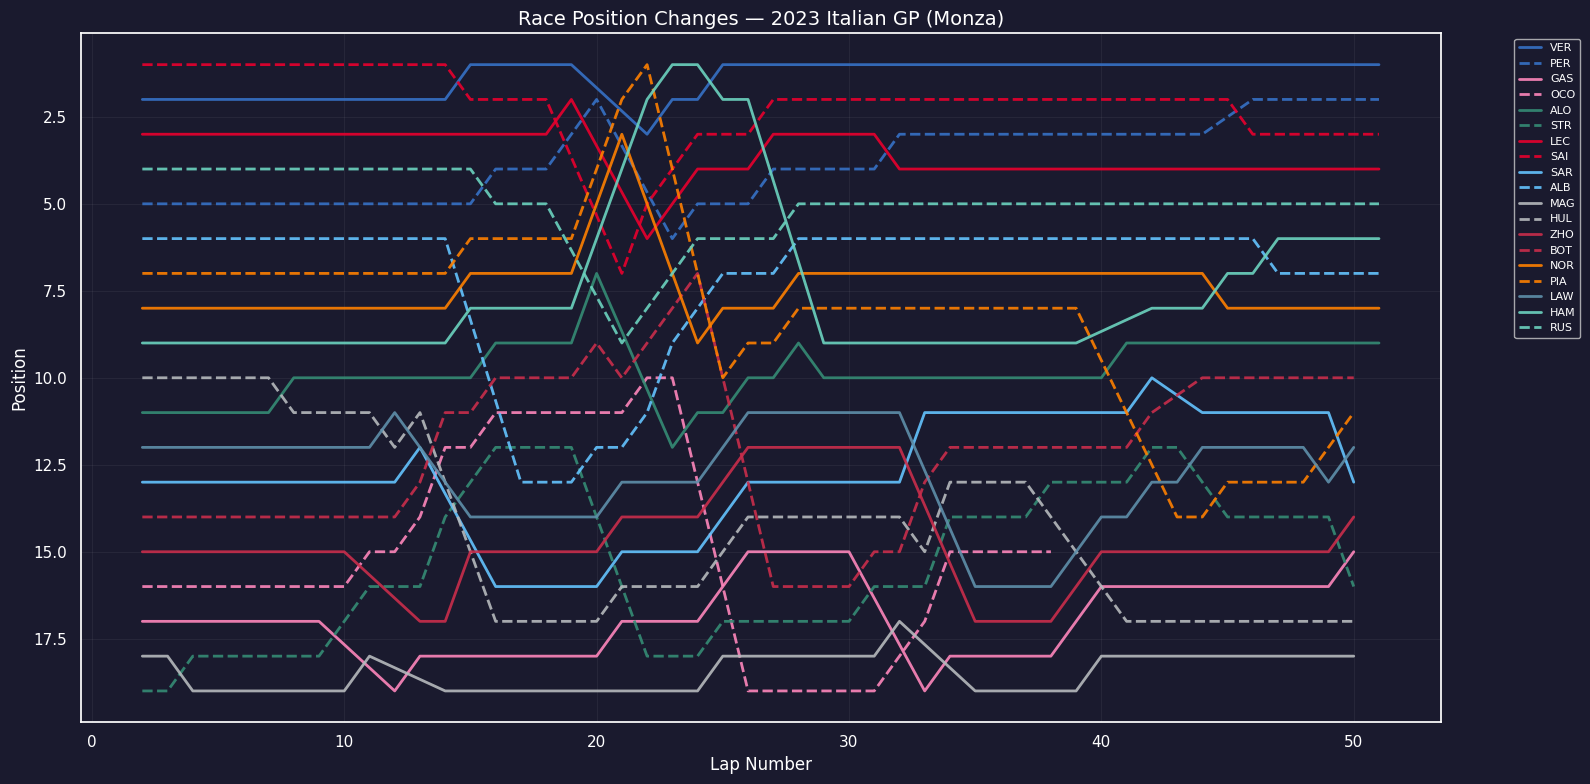

Plot saved


In [7]:
# Get one entry per driver per lap (their position)
position_data = laps[['Driver', 'LapNumber', 'Position', 'Team']].dropna()

team_colors = {
    'Red Bull Racing': '#3671C6',
    'Mercedes': '#6CD3BF',
    'Ferrari': '#E8002D',
    'McLaren': '#FF8000',
    'Aston Martin': '#358C75',
    'Alpine': '#FF87BC',
    'Williams': '#64C4FF',
    'AlphaTauri': '#5E8FAA',
    'Alfa Romeo': '#C92D4B',
    'Haas F1 Team': '#B6BABD'
}

driver_team = laps[['Driver', 'Team']].drop_duplicates()
driver_color = {
    row['Driver']: team_colors.get(row['Team'], '#FFFFFF')
    for _, row in driver_team.iterrows()
}

team_drivers = {}
for _, row in driver_team.iterrows():
    team_drivers.setdefault(row['Team'], []).append(row['Driver'])

plt.figure(figsize=(16, 8), facecolor='#1a1a2e')
ax = plt.gca()
ax.set_facecolor('#1a1a2e')

for team, drivers in team_drivers.items():
    for i, driver in enumerate(drivers):
        driver_data = position_data[position_data['Driver'] == driver]
        linestyle = '-' if i == 0 else '--'  # teammates distinguished by line style
        ax.plot(driver_data['LapNumber'], driver_data['Position'],
                linewidth=2, label=driver, alpha=0.9,
                color=driver_color[driver],
                linestyle=linestyle)

ax.invert_yaxis()
ax.set_xlabel('Lap Number', color='white')
ax.set_ylabel('Position', color='white')
ax.set_title('Race Position Changes — 2023 Italian GP (Monza)',
             color='white', fontsize=14)
ax.tick_params(colors='white')

# Grid lines — subtle, almost invisible
ax.grid(True, color='white', alpha=0.08, linewidth=0.5)

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left',
          fontsize=8, facecolor='#1a1a2e', labelcolor='white')
plt.tight_layout()

save_path = '/home/bkm/Downloads/Desktop/F1 EDA Project/f1-eda/outputs/figures/position_changes.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")

In [ ]:
#Note: Yuki Tsunoda (TSU) is absent from this dataset because he suffered an engine failure on the formation lap and never started the race — a DNS (Did Not Start). This is not a data error.

In [8]:
# Find first and last recorded position for each driver
position_changes = []

for driver in laps['Driver'].unique():
    driver_laps = laps[laps['Driver'] == driver].sort_values('LapNumber')
    first_pos = driver_laps.iloc[0]['Position']
    last_pos = driver_laps.iloc[-1]['Position']
    total_laps = driver_laps['LapNumber'].max()
    gained = first_pos - last_pos  # positive = gained positions
    
    position_changes.append({
        'Driver': driver,
        'StartPosition': first_pos,
        'EndPosition': last_pos,
        'PositionsGained': gained,
        'LapsCompleted': total_laps
    })

pos_df = pd.DataFrame(position_changes).sort_values('PositionsGained', ascending=False)
print(pos_df.to_string(index=False))

Driver  StartPosition  EndPosition  PositionsGained  LapsCompleted
   BOT           14.0         10.0              4.0           50.0
   STR           19.0         16.0              3.0           50.0
   PER            5.0          2.0              3.0           51.0
   HAM            9.0          6.0              3.0           51.0
   GAS           17.0         15.0              2.0           50.0
   ALO           11.0          9.0              2.0           51.0
   VER            2.0          1.0              1.0           51.0
   ZHO           15.0         14.0              1.0           50.0
   OCO           16.0         15.0              1.0           38.0
   MAG           18.0         18.0              0.0           50.0
   SAR           13.0         13.0              0.0           50.0
   LAW           12.0         12.0              0.0           50.0
   NOR            8.0          8.0              0.0           51.0
   LEC            3.0          4.0             -1.0           

In [ ]:
## 2. Tyre Compound vs Lap Time
Which tyre compound produced the fastest laps? 
A box plot shows the distribution of lap times for each compound.

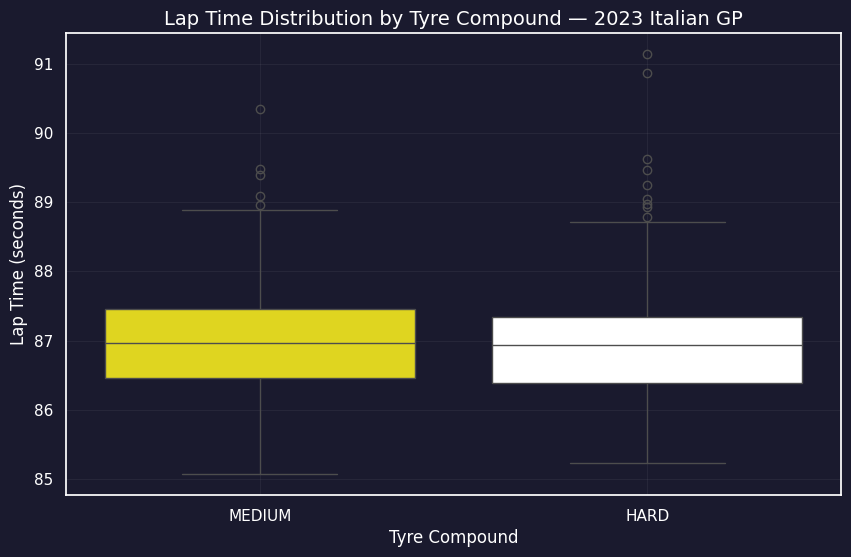

Plot saved


In [12]:
# Filter out outliers — pit laps and safety car laps skew the data
clean = laps[laps['LapTime'] < 120]

plt.figure(figsize=(10, 6), facecolor='#1a1a2e')
ax = plt.gca()
ax.set_facecolor('#1a1a2e')

compound_colors = {
    'MEDIUM': '#FFF200',
    'HARD': '#FFFFFF'
}

sns.boxplot(data=clean, x='Compound', y='LapTime',
            hue='Compound', palette=compound_colors, ax=ax,
            order=['MEDIUM', 'HARD'], legend=False)

ax.set_xlabel('Tyre Compound', color='white')
ax.set_ylabel('Lap Time (seconds)', color='white')
ax.set_title('Lap Time Distribution by Tyre Compound — 2023 Italian GP',
             color='white', fontsize=14)
ax.tick_params(colors='white')
ax.grid(True, color='white', alpha=0.08, linewidth=0.5)

save_path = '/home/bkm/Downloads/Desktop/F1 EDA Project/f1-eda/outputs/figures/compound_laptimes.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")

In [11]:
print(clean['Compound'].value_counts())


Compound
HARD      467
MEDIUM    397
Name: count, dtype: int64
